### Lang chain Using SQL lite

In [1]:
%load_ext dotenv
%dotenv
%load_ext mypy_ipython

In [2]:
from langchain_openai.chat_models import  ChatOpenAI
from langgraph.graph import  START , END , StateGraph , MessagesState
from langchain_core.messages import  AIMessage , SystemMessage , HumanMessage , RemoveMessage
#from  langgraph.checkpoint.memory import  InMemorySaver
from   langgraph.checkpoint.sqlite  import  SqliteSaver
import sqlite3

In [3]:
chat = ChatOpenAI(
    model='gpt-4o',
    seed=356,
    max_tokens=500,
    temperature=0.8
)

In [4]:
class State(MessagesState):
    summery : str

In [5]:
def ask_question(state: State) -> State:
    print(f"\n-------> ENTERING ask_question:")
    question = "What is your question?"
    print(question)

    return State(
        messages = [AIMessage(question), HumanMessage(input())]
    )

In [6]:
def chat_bot(state : State) -> State:
    print(f'\n---------------chat_bot Started')
    for i in state['messages']:
        i.pretty_print()

    # adding logic to get summary to latest question instead of all previous inputs

    system_message = f'''
        Here's a quick summary of what's been discussed so far:
        {state.get('summery','')}
        Keep this in mind as you answer the next question.
    '''
    response = chat.invoke(
        [SystemMessage(system_message)] + state["messages"]
    )

    response.pretty_print()

    return State(
        messages = [response]
    )

In [7]:
def summarize(state: State) -> State:
    print(f"\n-------> ENTERING trim_messages:")
    new_conversation = ""
    for i in state["messages"]:
        new_conversation += f"{i.type}: {i.content}\n\n"

    summary_instructions = f'''
        Update the ongoing summary by incorporating the new lines of conversation below.
        Build upon the previous summary rather than repeating it so that the result
        reflects the most recent context and developments.

        Previous Summary:
        {state.get("summery", "")}

        New Conversation:
        {new_conversation}
        '''
    summary = chat.invoke([HumanMessage(summary_instructions)])
    remove_messages = [RemoveMessage(id = i.id) for i in state["messages"][:]]

    return State(
        messages = remove_messages,
        summary = summary.content
    )


In [8]:
graph = StateGraph(State)
graph.add_node("ask_question", ask_question)
graph.add_node("chat_bot",chat_bot)
graph.add_node("summarize",summarize)

graph.add_edge(START, "ask_question")
graph.add_edge("ask_question", "chat_bot")
graph.add_edge("chat_bot", "summarize")
graph.add_edge('summarize', END)


In [9]:
dbpath = 'C:/Users/akhil/Langgraph/SqlLite/SqlLite.db'

In [10]:
con = sqlite3.connect(dbpath , check_same_thread=False)
check_point = SqliteSaver(con)

In [11]:
graph_compiled = graph.compile(check_point)

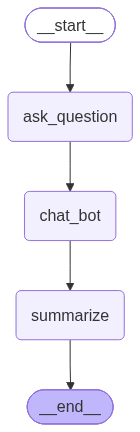

In [12]:
graph_compiled

In [13]:
config1 = {
    "configurable": {
        "thread_id": "user-1"
    }
}

In [14]:
graph_compiled.invoke({}, config1)


-------> ENTERING ask_question:
What is your question?


KeyboardInterrupt: Interrupted by user

In [ ]:
graph_steps = [ i for i in graph_compiled.get_state_history(config=config1)]

In [ ]:
for i in graph_steps:
    print(i)